# Module 6 Custom Project: Wine Cultivar Model and Serving Artifact

**Author:** Oluwafemi Salawu
  
**Repository:** `ml-06-serving`

## Project question

Given the chemical measurements of a wine sample, can a machine-learning model predict its cultivar?

## Technical modification

This notebook applies Module 6 skills to a new problem by:

- replacing the penguin dataset with scikit-learn's wine dataset,
- comparing a Decision Tree with a Random Forest,
- using stratified cross-validation,
- creating a confusion matrix and feature-importance chart,
- saving a serving-ready model bundle,
- validating API-style prediction input,
- and writing all major results to `project.log`.

## Important

Run this notebook from the repository's `notebooks` folder.

Use:

**Kernel → Restart Kernel and Run All Cells**

This produces:

- `project.log` in the repository root,
- `artifacts/wine_model_bundle.joblib`,
- charts displayed in the notebook.

In [1]:
# === Section 1. Imports, paths, and logger configuration ===

import logging
from pathlib import Path
from typing import Any, Final

from datafun_toolkit.logger import get_logger, log_header
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.tree import DecisionTreeClassifier

# The notebook is expected to run from ml-06-serving/notebooks.
NOTEBOOK_DIR: Final[Path] = Path.cwd()
PROJECT_ROOT: Final[Path] = NOTEBOOK_DIR.parent
ARTIFACTS_DIR: Final[Path] = PROJECT_ROOT / "artifacts"
MODEL_PATH: Final[Path] = ARTIFACTS_DIR / "wine_model_bundle.joblib"
PROJECT_LOG_PATH: Final[Path] = PROJECT_ROOT / "project.log"

RANDOM_STATE: Final[int] = 42
TEST_SIZE: Final[float] = 0.20

LOG: logging.Logger = get_logger("M06", level="DEBUG")
log_header(LOG, "M06")

LOG.info("========================")
LOG.info("START CUSTOM NOTEBOOK")
LOG.info("========================")
LOG.info(f"Notebook directory: {NOTEBOOK_DIR}")
LOG.info(f"Project root: {PROJECT_ROOT}")
LOG.info(f"Expected project log: {PROJECT_LOG_PATH}")
LOG.info(f"Model artifact path: {MODEL_PATH}")

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Expected project log: {PROJECT_LOG_PATH}")
print(f"Model artifact path: {MODEL_PATH}")

2026-07-26 16:47:46 | INFO | M06 | === RUN START ===
2026-07-26 16:47:46 | INFO | M06 | project=M06
2026-07-26 16:47:46 | INFO | M06 | repo_dir=ml-06-serving
2026-07-26 16:47:46 | INFO | M06 | python=3.14.2
2026-07-26 16:47:46 | INFO | M06 | os=Windows 11
2026-07-26 16:47:46 | INFO | M06 | shell=powershell
2026-07-26 16:47:46 | INFO | M06 | cwd=notebooks
2026-07-26 16:47:46 | INFO | M06 | github_actions=False
2026-07-26 16:47:46 | INFO | M06 | ========================
2026-07-26 16:47:46 | INFO | M06 | START CUSTOM NOTEBOOK
2026-07-26 16:47:46 | INFO | M06 | ========================
2026-07-26 16:47:46 | INFO | M06 | Notebook directory: c:\Repos\ml-06-serving\notebooks
2026-07-26 16:47:46 | INFO | M06 | Project root: c:\Repos\ml-06-serving
2026-07-26 16:47:46 | INFO | M06 | Expected project log: c:\Repos\ml-06-serving\project.log
2026-07-26 16:47:46 | INFO | M06 | Model artifact path: c:\Repos\ml-06-serving\artifacts\wine_model_bundle.joblib


Notebook directory: c:\Repos\ml-06-serving\notebooks
Project root: c:\Repos\ml-06-serving
Expected project log: c:\Repos\ml-06-serving\project.log
Model artifact path: c:\Repos\ml-06-serving\artifacts\wine_model_bundle.joblib


## 1. Load the wine dataset

The dataset contains chemical measurements for three wine cultivars.

In [2]:
# === Section 2. Load and inspect the data ===

LOG.info("Load data.................")

wine = load_wine(as_frame=True)
df: pd.DataFrame = wine.frame.copy()

TARGET_COL: Final[str] = "target"
FEATURE_COLS: Final[list[str]] = list(wine.feature_names)
TARGET_NAMES: Final[list[str]] = list(wine.target_names)

target_name_map = {index: name for index, name in enumerate(TARGET_NAMES)}
df["cultivar_name"] = df[TARGET_COL].map(target_name_map)

LOG.info("Loading dataset: sklearn wine")
LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
LOG.info(f"Features: {FEATURE_COLS}")
LOG.info(f"Target classes: {TARGET_NAMES}")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Target classes: {TARGET_NAMES}")

df.head()

2026-07-26 16:47:46 | INFO | M06 | Load data.................
2026-07-26 16:47:46 | INFO | M06 | Loading dataset: sklearn wine
2026-07-26 16:47:46 | INFO | M06 | Loaded: 178 rows, 15 columns
2026-07-26 16:47:46 | INFO | M06 | Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
2026-07-26 16:47:46 | INFO | M06 | Target classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


Rows: 178
Columns: 15
Features: 13
Target classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cultivar_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [3]:
# === Section 3. Check data quality ===

LOG.info("Check data quality........")

missing_total: int = int(df.isna().sum().sum())
duplicate_rows: int = int(df.duplicated().sum())

LOG.info(f"Missing values: {missing_total}")
LOG.info(f"Duplicate rows: {duplicate_rows}")
LOG.info("Class counts:")
for class_name, count in df["cultivar_name"].value_counts().items():
    LOG.info(f"  {class_name}: {count}")

print("Missing values:", missing_total)
print("Duplicate rows:", duplicate_rows)
print("\nClass counts:")
print(df["cultivar_name"].value_counts())

2026-07-26 16:47:46 | INFO | M06 | Check data quality........
2026-07-26 16:47:46 | INFO | M06 | Missing values: 0
2026-07-26 16:47:46 | INFO | M06 | Duplicate rows: 0
2026-07-26 16:47:46 | INFO | M06 | Class counts:
2026-07-26 16:47:46 | INFO | M06 |   class_1: 71
2026-07-26 16:47:46 | INFO | M06 |   class_0: 59
2026-07-26 16:47:46 | INFO | M06 |   class_2: 48


Missing values: 0
Duplicate rows: 0

Class counts:
cultivar_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [4]:
# Review descriptive statistics.

summary_df = df[FEATURE_COLS].describe().T
summary_df

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## 2. Split the data

A stratified train-test split preserves the class proportions.

In [5]:
# === Section 4. Split into training and testing sets ===

LOG.info("Split data................")

X: pd.DataFrame = df[FEATURE_COLS].copy()
y: pd.Series = df[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

2026-07-26 16:47:46 | INFO | M06 | Split data................
2026-07-26 16:47:46 | INFO | M06 | Train instances: 142
2026-07-26 16:47:46 | INFO | M06 | Test instances: 36


Training rows: 142
Testing rows: 36


## 3. Train a baseline and an ensemble model

The Decision Tree is the baseline.  
The Random Forest is the ensemble model selected for serving.

In [6]:
# === Section 5. Train the models ===

LOG.info("Train models..............")

decision_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=RANDOM_STATE,
)

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

LOG.info("Training DecisionTreeClassifier")
decision_tree.fit(X_train, y_train)

LOG.info("Training RandomForestClassifier")
random_forest.fit(X_train, y_train)

LOG.info("Training complete")
print("Training complete.")

2026-07-26 16:47:46 | INFO | M06 | Train models..............
2026-07-26 16:47:46 | INFO | M06 | Training DecisionTreeClassifier
2026-07-26 16:47:46 | INFO | M06 | Training RandomForestClassifier
2026-07-26 16:47:47 | INFO | M06 | Training complete


Training complete.


In [7]:
# === Section 6. Compare held-out test accuracy ===

LOG.info("Evaluate models...........")

tree_predictions = decision_tree.predict(X_test)
forest_predictions = random_forest.predict(X_test)

tree_accuracy: float = float(accuracy_score(y_test, tree_predictions))
forest_accuracy: float = float(accuracy_score(y_test, forest_predictions))

LOG.info(f"Decision Tree test accuracy: {tree_accuracy:.3f}")
LOG.info(f"Random Forest test accuracy: {forest_accuracy:.3f}")

results_df = pd.DataFrame(
    {
        "model": ["Decision Tree", "Random Forest"],
        "test_accuracy": [tree_accuracy, forest_accuracy],
    }
).sort_values("test_accuracy", ascending=False)

results_df

2026-07-26 16:47:47 | INFO | M06 | Evaluate models...........
2026-07-26 16:47:47 | INFO | M06 | Decision Tree test accuracy: 0.944
2026-07-26 16:47:47 | INFO | M06 | Random Forest test accuracy: 1.000


,model,test_accuracy
1,Random Forest,1.000000
0,Decision Tree,0.944444


## 4. Apply a new evaluation skill: cross-validation

Five-fold stratified cross-validation provides stronger evidence than relying on one train-test split.

In [8]:
# === Section 7. Cross-validation ===

LOG.info("Cross-validate model......")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
)

cv_mean: float = float(cv_scores.mean())
cv_std: float = float(cv_scores.std())

LOG.info(f"Cross-validation scores: {np.round(cv_scores, 3).tolist()}")
LOG.info(f"Mean CV accuracy: {cv_mean:.3f}")
LOG.info(f"CV standard deviation: {cv_std:.3f}")

print("Cross-validation scores:", np.round(cv_scores, 3))
print(f"Mean CV accuracy: {cv_mean:.3f}")
print(f"CV standard deviation: {cv_std:.3f}")

2026-07-26 16:47:47 | INFO | M06 | Cross-validate model......
2026-07-26 16:47:52 | INFO | M06 | Cross-validation scores: [0.972, 1.0, 1.0, 0.943, 1.0]
2026-07-26 16:47:52 | INFO | M06 | Mean CV accuracy: 0.983
2026-07-26 16:47:52 | INFO | M06 | CV standard deviation: 0.023


Cross-validation scores: [0.972 1.    1.    0.943 1.   ]
Mean CV accuracy: 0.983
CV standard deviation: 0.023


## 5. Review classification results

In [9]:
# === Section 8. Classification report ===

LOG.info("Create classification report")

report_text: str = classification_report(
    y_test,
    forest_predictions,
    target_names=TARGET_NAMES,
)

LOG.info("Classification report:")
for line in report_text.splitlines():
    LOG.info(line)

print(report_text)

2026-07-26 16:47:52 | INFO | M06 | Create classification report
2026-07-26 16:47:52 | INFO | M06 | Classification report:
2026-07-26 16:47:52 | INFO | M06 |               precision    recall  f1-score   support
2026-07-26 16:47:52 | INFO | M06 | 
2026-07-26 16:47:52 | INFO | M06 |      class_0       1.00      1.00      1.00        12
2026-07-26 16:47:52 | INFO | M06 |      class_1       1.00      1.00      1.00        14
2026-07-26 16:47:52 | INFO | M06 |      class_2       1.00      1.00      1.00        10
2026-07-26 16:47:52 | INFO | M06 | 
2026-07-26 16:47:52 | INFO | M06 |     accuracy                           1.00        36
2026-07-26 16:47:52 | INFO | M06 |    macro avg       1.00      1.00      1.00        36
2026-07-26 16:47:52 | INFO | M06 | weighted avg       1.00      1.00      1.00        36


              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



2026-07-26 16:47:53 | INFO | M06 | Create confusion matrix chart


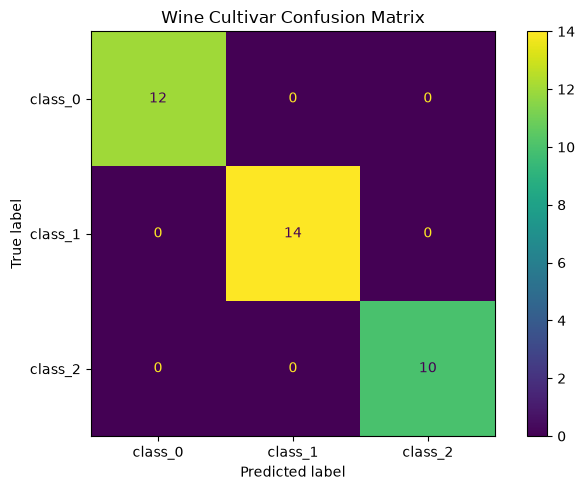

In [10]:
# === Section 9. Confusion matrix ===

LOG.info("Create confusion matrix chart")

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_predictions,
    display_labels=TARGET_NAMES,
    ax=ax,
)

ax.set_title("Wine Cultivar Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. Interpret the Random Forest

Feature importance helps explain which chemical measurements contributed most strongly to the predictions.

In [11]:
# === Section 10. Feature importance ===

LOG.info("Calculate feature importance")

importance_df = (
    pd.DataFrame(
        {
            "feature": FEATURE_COLS,
            "importance": random_forest.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

LOG.info("Top five features:")
for row in importance_df.head(5).itertuples(index=False):
    LOG.info(f"  {row.feature}: {row.importance:.3f}")

importance_df

2026-07-26 16:47:53 | INFO | M06 | Calculate feature importance
2026-07-26 16:47:53 | INFO | M06 | Top five features:
2026-07-26 16:47:53 | INFO | M06 |   color_intensity: 0.181
2026-07-26 16:47:53 | INFO | M06 |   flavanoids: 0.173
2026-07-26 16:47:53 | INFO | M06 |   proline: 0.151
2026-07-26 16:47:53 | INFO | M06 |   alcohol: 0.112
2026-07-26 16:47:53 | INFO | M06 |   hue: 0.100


,feature,importance
0,color_intensity,0.180805
1,flavanoids,0.172865
2,proline,0.151067
3,alcohol,0.112384
4,hue,0.099592
5,od280/od315_of_diluted_wines,0.090361
6,total_phenols,0.051563
7,malic_acid,0.033140
8,magnesium,0.032820
9,alcalinity_of_ash,0.026338


2026-07-26 16:47:53 | INFO | M06 | Create feature importance chart


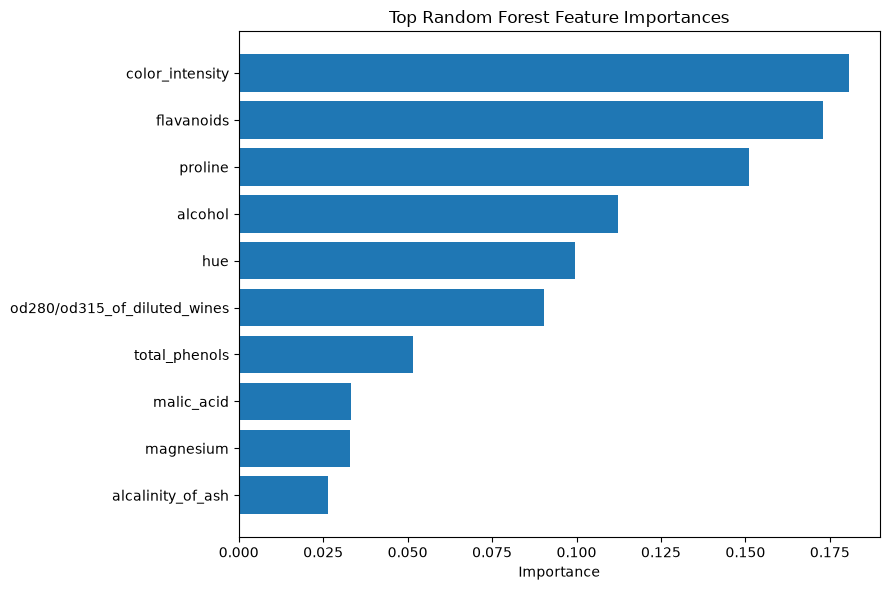

In [12]:
# === Section 11. Feature importance chart ===

LOG.info("Create feature importance chart")

top_features = importance_df.head(10).sort_values(
    "importance",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features["feature"], top_features["importance"])
ax.set_title("Top Random Forest Feature Importances")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 7. Save a serving-ready model bundle

The original example saves only the model. This technical modification saves:

- the trained model,
- feature names,
- target names,
- feature validation ranges,
- performance metadata.

A FastAPI service can load this information from one artifact.

In [13]:
# === Section 12. Build and save the model bundle ===

LOG.info("Save model bundle.........")

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

feature_ranges: dict[str, dict[str, float]] = {
    feature: {
        "min": float(X_train[feature].min()),
        "max": float(X_train[feature].max()),
    }
    for feature in FEATURE_COLS
}

model_bundle: dict[str, Any] = {
    "model": random_forest,
    "feature_names": FEATURE_COLS,
    "target_names": TARGET_NAMES,
    "feature_ranges": feature_ranges,
    "metadata": {
        "project": "Module 6 Wine Cultivar Classifier",
        "problem_type": "multiclass_classification",
        "dataset": "sklearn.datasets.load_wine",
        "random_state": RANDOM_STATE,
        "training_rows": int(len(X_train)),
        "testing_rows": int(len(X_test)),
        "test_accuracy": forest_accuracy,
        "mean_cv_accuracy": cv_mean,
        "cv_std_accuracy": cv_std,
    },
}

joblib.dump(model_bundle, MODEL_PATH)

LOG.info(f"Saved model bundle to: {MODEL_PATH}")
LOG.info(f"Artifact exists: {MODEL_PATH.exists()}")

print(f"Saved model bundle to: {MODEL_PATH}")
print(f"Artifact exists: {MODEL_PATH.exists()}")

2026-07-26 16:47:53 | INFO | M06 | Save model bundle.........
2026-07-26 16:47:54 | INFO | M06 | Saved model bundle to: c:\Repos\ml-06-serving\artifacts\wine_model_bundle.joblib
2026-07-26 16:47:54 | INFO | M06 | Artifact exists: True


Saved model bundle to: c:\Repos\ml-06-serving\artifacts\wine_model_bundle.joblib
Artifact exists: True


## 8. Create a serving-style prediction function

The function below accepts a dictionary like a JSON request body.

It checks for:

- missing features,
- nonnumeric values,
- values outside the training range.

It returns:

- the predicted cultivar,
- probabilities for all cultivars,
- warnings for unusual values.

In [14]:
# === Section 13. Define API-style prediction logic ===


def predict_from_payload(
    bundle: dict[str, Any],
    payload: dict[str, Any],
) -> dict[str, Any]:
    """Validate a dictionary payload and return a prediction."""

    model = bundle["model"]
    feature_names: list[str] = bundle["feature_names"]
    target_names: list[str] = bundle["target_names"]
    feature_ranges: dict[str, dict[str, float]] = bundle["feature_ranges"]

    missing_features = [feature for feature in feature_names if feature not in payload]

    if missing_features:
        raise ValueError(f"Missing required features: {missing_features}")

    values: list[float] = []
    warnings: list[str] = []

    for feature in feature_names:
        try:
            value = float(payload[feature])
        except (TypeError, ValueError) as exc:
            raise ValueError(f"Feature '{feature}' must be numeric.") from exc

        minimum = feature_ranges[feature]["min"]
        maximum = feature_ranges[feature]["max"]

        if value < minimum or value > maximum:
            warnings.append(
                f"{feature}={value} is outside the training "
                f"range [{minimum}, {maximum}]."
            )

        values.append(value)

    input_df = pd.DataFrame(
        [values],
        columns=feature_names,
    )

    class_index: int = int(model.predict(input_df)[0])
    probabilities = model.predict_proba(input_df)[0]

    return {
        "prediction": target_names[class_index],
        "probabilities": {
            target_names[index]: round(float(probability), 4)
            for index, probability in enumerate(probabilities)
        },
        "warnings": warnings,
    }


LOG.info("Prediction function created")

2026-07-26 16:47:54 | INFO | M06 | Prediction function created


In [15]:
# === Section 14. Test a valid prediction request ===

LOG.info("Test valid prediction request")

sample_payload: dict[str, float] = X_test.iloc[0].astype(float).to_dict()

prediction_result = predict_from_payload(
    model_bundle,
    sample_payload,
)

LOG.info(f"Sample payload: {sample_payload}")
LOG.info(f"Predicted cultivar: {prediction_result['prediction']}")
LOG.info(f"Prediction probabilities: {prediction_result['probabilities']}")

prediction_result

2026-07-26 16:47:54 | INFO | M06 | Test valid prediction request
2026-07-26 16:47:54 | INFO | M06 | Sample payload: {'alcohol': 14.1, 'malic_acid': 2.16, 'ash': 2.3, 'alcalinity_of_ash': 18.0, 'magnesium': 105.0, 'total_phenols': 2.95, 'flavanoids': 3.32, 'nonflavanoid_phenols': 0.22, 'proanthocyanins': 2.38, 'color_intensity': 5.75, 'hue': 1.25, 'od280/od315_of_diluted_wines': 3.17, 'proline': 1510.0}
2026-07-26 16:47:54 | INFO | M06 | Predicted cultivar: class_0
2026-07-26 16:47:54 | INFO | M06 | Prediction probabilities: {np.str_('class_0'): 0.99, np.str_('class_1'): 0.01, np.str_('class_2'): 0.0}


{'prediction': np.str_('class_0'),
 'probabilities': {np.str_('class_0'): 0.99,
  np.str_('class_1'): 0.01,
  np.str_('class_2'): 0.0},
 'warnings': []}

In [16]:
# === Section 15. Test input validation ===

LOG.info("Test missing-feature validation")

invalid_payload = sample_payload.copy()
removed_feature = FEATURE_COLS[0]
invalid_payload.pop(removed_feature)

try:
    predict_from_payload(model_bundle, invalid_payload)
except ValueError as exc:
    LOG.info(f"Validation test passed: {exc}")
    print("Validation test passed:")
    print(exc)

2026-07-26 16:47:54 | INFO | M06 | Test missing-feature validation
2026-07-26 16:47:54 | INFO | M06 | Validation test passed: Missing required features: ['alcohol']


Validation test passed:
Missing required features: ['alcohol']


## 9. Final findings

After running all cells, use the logged results to describe:

1. Which model performed better.
2. Whether cross-validation supported the held-out test result.
3. Which chemical features were most important.
4. Whether the confusion matrix showed any misclassified cultivars.
5. Why saving metadata with the model improves the serving workflow.

In [17]:
# === Section 16. Final project summary ===

best_model_name = (
    "Random Forest" if forest_accuracy >= tree_accuracy else "Decision Tree"
)

top_feature_name: str = str(importance_df.iloc[0]["feature"])
top_feature_importance: float = float(importance_df.iloc[0]["importance"])

LOG.info("========================")
LOG.info("CUSTOM PROJECT SUMMARY")
LOG.info("========================")
LOG.info("Dataset: sklearn wine")
LOG.info("Target: wine cultivar")
LOG.info(f"Feature count: {len(FEATURE_COLS)}")
LOG.info(f"Best held-out model: {best_model_name}")
LOG.info(f"Decision Tree accuracy: {tree_accuracy:.3f}")
LOG.info(f"Random Forest accuracy: {forest_accuracy:.3f}")
LOG.info(f"Mean CV accuracy: {cv_mean:.3f}")
LOG.info(f"CV standard deviation: {cv_std:.3f}")
LOG.info(f"Top feature: {top_feature_name} ({top_feature_importance:.3f})")
LOG.info(f"Saved artifact: {MODEL_PATH}")
LOG.info("========================")
LOG.info("Notebook executed successfully!")
LOG.info("========================")

print("========================")
print("CUSTOM PROJECT SUMMARY")
print("========================")
print("Dataset: sklearn wine")
print("Target: wine cultivar")
print(f"Feature count: {len(FEATURE_COLS)}")
print(f"Best held-out model: {best_model_name}")
print(f"Decision Tree accuracy: {tree_accuracy:.3f}")
print(f"Random Forest accuracy: {forest_accuracy:.3f}")
print(f"Mean CV accuracy: {cv_mean:.3f}")
print(f"CV standard deviation: {cv_std:.3f}")
print(f"Top feature: {top_feature_name} ({top_feature_importance:.3f})")
print(f"Saved artifact: {MODEL_PATH}")
print(f"Check project log at: {PROJECT_LOG_PATH}")
print("========================")
print("Notebook executed successfully!")
print("========================")

2026-07-26 16:47:54 | INFO | M06 | ========================
2026-07-26 16:47:54 | INFO | M06 | CUSTOM PROJECT SUMMARY
2026-07-26 16:47:54 | INFO | M06 | ========================
2026-07-26 16:47:54 | INFO | M06 | Dataset: sklearn wine
2026-07-26 16:47:54 | INFO | M06 | Target: wine cultivar
2026-07-26 16:47:54 | INFO | M06 | Feature count: 13
2026-07-26 16:47:54 | INFO | M06 | Best held-out model: Random Forest
2026-07-26 16:47:54 | INFO | M06 | Decision Tree accuracy: 0.944
2026-07-26 16:47:54 | INFO | M06 | Random Forest accuracy: 1.000
2026-07-26 16:47:54 | INFO | M06 | Mean CV accuracy: 0.983
2026-07-26 16:47:54 | INFO | M06 | CV standard deviation: 0.023
2026-07-26 16:47:54 | INFO | M06 | Top feature: color_intensity (0.181)
2026-07-26 16:47:54 | INFO | M06 | Saved artifact: c:\Repos\ml-06-serving\artifacts\wine_model_bundle.joblib
2026-07-26 16:47:54 | INFO | M06 | ========================
2026-07-26 16:47:54 | INFO | M06 | Notebook executed successfully!
2026-07-26 16:47:54 | IN

CUSTOM PROJECT SUMMARY
Dataset: sklearn wine
Target: wine cultivar
Feature count: 13
Best held-out model: Random Forest
Decision Tree accuracy: 0.944
Random Forest accuracy: 1.000
Mean CV accuracy: 0.983
CV standard deviation: 0.023
Top feature: color_intensity (0.181)
Saved artifact: c:\Repos\ml-06-serving\artifacts\wine_model_bundle.joblib
Check project log at: c:\Repos\ml-06-serving\project.log
Notebook executed successfully!
